In [40]:
import warnings 
import pandas as pd 
from sklearn import model_selection 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix 
import matplotlib.pyplot as plt 
%matplotlib inline  
 


In [41]:
#ignore warnings 
warnings.filterwarnings('ignore') 
# Load digits dataset 
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data" 
df = pd.read_csv(url) 
# df = df.values 
X = df.iloc[:,0:4] 
y = df.iloc[:,4] 
#test size 
test_size = 0.33 
#generate the same set of random numbers 
seed = 7 
#Split data into train and test set. 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_size, random_state=seed) 
#Train Model 
model = LogisticRegression() 
model.fit(X_train, y_train) 
pred = model.predict(X_test) 
 


In [42]:
from sklearn.datasets import load_iris

# Load iris dataset locally
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
X = df.iloc[:,0:4]
y = df.iloc[:,4]

In [43]:
labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'] 
cm = confusion_matrix(y_test, pred) 
print(cm) 

[[13  0  0]
 [ 0 17  2]
 [ 0  0 18]]


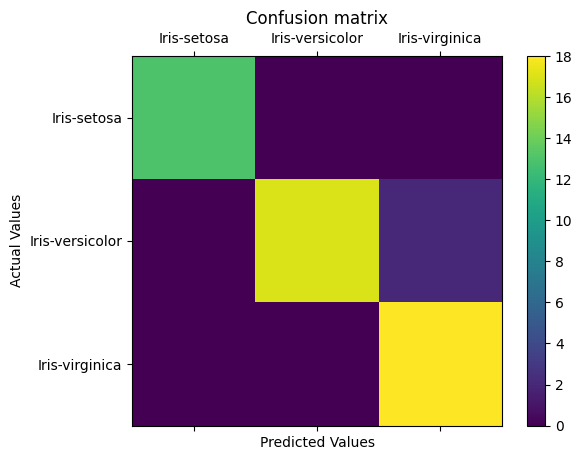

In [44]:
fig = plt.figure() 
ax = fig.add_subplot(111) 
cax = ax.matshow(cm) 
plt.title('Confusion matrix') 
fig.colorbar(cax) 
ax.set_xticklabels([''] + labels) 
ax.set_yticklabels([''] + labels) 
plt.xlabel('Predicted Values') 
plt.ylabel('Actual Values') 
plt.show()

Accuracy

In [45]:
from sklearn import datasets 
from sklearn.metrics import accuracy_score 

In [46]:
#ignore warnings 
warnings.filterwarnings('ignore') 
# Load digits dataset 
iris = datasets.load_iris() 
# # Create feature matrix 
X = iris.data 
# Create target vector 
y = iris.target 
#test size 
test_size = 0.33 
#generate the same set of random numbers 
seed = 7 

In [47]:
#cross-validation settings 
kfold = model_selection.KFold(n_splits=10, random_state=seed, shuffle=True) 
#Model instance 
model = LogisticRegression() 

In [48]:
#Evaluate model performance 
scoring = 'accuracy' 
results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring) 
print('Accuracy -val set: %.2f%% (%.2f)' % (results.mean()*100, results.std())) 

Accuracy -val set: 96.67% (0.05)


In [49]:
#split data 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_size, random_state=seed) 


In [50]:
#fit model 
model.fit(X_train, y_train) 
#accuracy on test set 
result = model.score(X_test, y_test) 
print("Accuracy - test set: %.2f%%" % (result*100.0))

Accuracy - test set: 92.00%


In [51]:
import warnings 
from sklearn import model_selection 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import log_loss 
from sklearn.metrics import precision_recall_fscore_support as score, precision_score, recall_score, f1_score 
 
warnings.filterwarnings('ignore') 

In [53]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv" 
dataframe = pd.read_csv(url) 
dat = dataframe.values 
X = dat[:,:-1] 
y = dat[:,-1] 
test_size = 0.33 
seed = 7 

In [54]:
model = LogisticRegression() 
#split data 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_size, random_state=seed) 
model.fit(X_train, y_train) 
pred = model.predict(X_test) 
precision = precision_score(y_test, pred) 
print('Precision: %f' % precision) 
# recall: tp / (tp + fn) 
recall = recall_score(y_test, pred) 
print('Recall: %f' % recall) 
# f1: tp / (tp + fp + fn) 
f1 = f1_score(y_test, pred) 
print('F1 score: %f' % f1)

Precision: 0.701493
Recall: 0.552941
F1 score: 0.618421


Receiver Operating Characteristics (ROC) Curve

In [55]:
import warnings 
import pandas 
from sklearn import model_selection 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import roc_auc_score, roc_curve 
 
warnings.filterwarnings('ignore') 

In [56]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv" 
dataframe = pandas.read_csv(url) 
dat = dataframe.values 
X = dat[:,:-1] 
y = dat[:,-1] 
seed = 7 
#split data 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_size, random_state=seed) 
model.fit(X_train, y_train) 

LogisticRegression()

In [57]:
# predict probabilities 
probs = model.predict_proba(X_test) 
# keep probabilities for the positive outcome only 
probs = probs[:, 1] 
 
auc = roc_auc_score(y_test, probs) 
print('AUC - Test Set: %.2f%%' % (auc*100)) 

AUC - Test Set: 82.85%


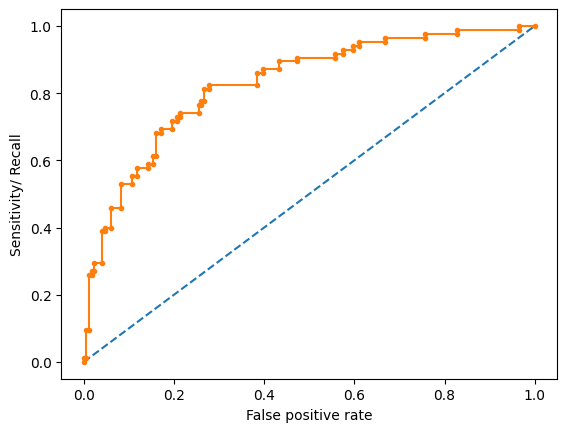

In [58]:
# calculate roc curve 
fpr, tpr, thresholds = roc_curve(y_test, probs) 
# plot no skill 
plt.plot([0, 1], [0, 1], linestyle='--') 
# plot the roc curve for the model 
plt.plot(fpr, tpr, marker='.') 
plt.xlabel('False positive rate') 
plt.ylabel('Sensitivity/ Recall') 
# show the plot 
plt.show()

Log Loss

In [59]:
import warnings 
import pandas 
from sklearn import model_selection 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import log_loss 
 
warnings.filterwarnings('ignore') 

In [60]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv" 
dataframe = pandas.read_csv(url) 
dat = dataframe.values 
X = dat[:,:-1] 
y = dat[:,-1] 
seed = 7 


In [61]:
#split data 
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_size, random_state=seed) 
model.fit(X_train, y_train) 


LogisticRegression()

In [62]:
#predict and compute logloss 
pred = model.predict(X_test) 
accuracy = log_loss(y_test, pred) 
print("Logloss: %.2f" % (accuracy))

Logloss: 8.23


Kolmogorov-Smirnov

In [63]:
from scipy.stats import kstest 
import random 
  
# N = int(input("Enter number of random numbers: ")) 
N = 10 
  
actual =[] 
print("Enter outcomes: ") 
  
for i in range(N): 
    # x = float(input("Outcomes of class "+str(i + 1)+": ")) 
    actual.append(random.random()) 
  
print(actual) 
x = kstest(actual, "norm")    
print(x)

Enter outcomes: 
[0.5900893134429883, 0.42214915619248294, 0.3327616510767901, 0.8192327059105279, 0.38927800687498415, 0.0752932789152434, 0.9722336602139207, 0.9967125417093403, 0.46552234923874436, 0.9617650154047634]
KstestResult(statistic=np.float64(0.5303428959773925), pvalue=np.float64(0.0037614889520007234), statistic_location=np.float64(0.3327616510767901), statistic_sign=np.int8(-1))
